In [1]:
import sys
from pathlib import Path
import inspect
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from matplotlib.patches import Patch
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1004/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
from phenoniche.v1001.neighborhoods import build_neighborhoods
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression, aggregate_pairwise_ccc
from phenoniche.v1002.final_model import fit_balanced
from phenoniche.v1004.composition_ccc_hierarchy import build_hierarchical_states

ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
OUTPUT=SOURCE.parent/'outputs/hbc1_hierarchical_niches'
OUTPUT.mkdir(parents=True,exist_ok=True)
assert all(Path(inspect.getfile(fn)).resolve().is_relative_to(SOURCE)
           for fn in (build_neighborhoods, load_lr_atlas, aggregate_pairwise_ccc,
                      fit_balanced, build_hierarchical_states))
N_NEIGHBORS=30
SIGMA_UM=20.0
K_NICHE=8
SEED=40700
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'
BATCH=256
plt.rcParams.update({'font.size':10,'figure.dpi':120,'savefig.dpi':220})


In [2]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
assert len(coordinates)==len(cell_type)==N and T==20


In [3]:
neighborhoods=build_neighborhoods(coordinates,k=N_NEIGHBORS,sigma=SIGMA_UM)
members=neighborhoods.indices.reshape(N,N_NEIGHBORS)
anchor_weights=neighborhoods.weights.reshape(N,N_NEIGHBORS).astype(np.float32)
C,_,opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,np.zeros((N,1),dtype=np.float32),np.zeros((N,1),dtype=np.float32),
    T,sigma=SIGMA_UM,members=members,anchor_weights=anchor_weights,
    batch_size=BATCH,device=DEVICE,compute_signal=False,
)
pair_support=(opportunity>0).sum(0)
assert np.allclose(C.sum(1),1,atol=1e-5)

atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')

I=np.empty((N,final_ccc),dtype=np.float32)
_,I,signal_opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,sigma=SIGMA_UM,
    members=members,anchor_weights=anchor_weights,feature_mask=feature_mask,
    batch_size=BATCH,device=DEVICE,communication_out=I,
)
assert np.allclose(opportunity,signal_opportunity,rtol=1e-5,atol=1e-6)
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()

assert C.shape==(N,T) and I.shape==(N,final_ccc) and members.shape[0]==N


In [4]:
fit_C=fit_balanced({'HC':C},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
fit_I=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W_C=np.maximum(fit_C.W.numpy(),0)
W_I=np.maximum(fit_I.W.numpy(),0)
W_C/=np.maximum(W_C.sum(1,keepdims=True),1e-12)
W_I/=np.maximum(W_I.sum(1,keepdims=True),1e-12)
c_labels=W_C.argmax(1)
i_labels=W_I.argmax(1)
assert W_C.shape==W_I.shape==(N,K_NICHE)

assert len(c_labels)==len(i_labels)==N
assert np.isfinite(W_C).all() and np.isfinite(W_I).all()


In [5]:
joint_id,joint_mapping=build_hierarchical_states(c_labels,i_labels,K_NICHE)
assert len(joint_id)==N and sum(row['n_cells'] for row in joint_mapping)==N
assert np.array_equal(np.array([(joint_mapping[j-1]['C_state'],joint_mapping[j-1]['I_state'])
                                for j in joint_id]),np.column_stack((c_labels,i_labels)))
pd.DataFrame({'cell_id':adata.obs.cell_id.to_numpy(),'x':coordinates[:,0],
              'y':coordinates[:,1],'cell_type':adata.obs.cell_type_coarse.to_numpy(),
              'C_state':c_labels,'I_state':i_labels,'joint_id':joint_id}).to_csv(
                  OUTPUT/'cell_states.csv',index=False)
pd.DataFrame(joint_mapping).to_csv(OUTPUT/'joint_state_mapping.csv',index=False)

# Retain the existing tab10 composition colors: C0 is #1f77b4 (blue).
single_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
assert mcolors.to_hex(single_colors[0])=='#1f77b4'
blue_state=next(k for k,color in enumerate(single_colors)
                if mcolors.to_hex(color)=='#1f77b4')

def joint_color(c,i):
    base=np.asarray(single_colors[c,:3])
    if i<=4:
        white_mix=(4-i)*0.14
        return base*(1-white_mix)+np.ones(3)*white_mix
    darkness=(i-4)*0.16
    return base*(1-darkness)

joint_palette={row['joint_id']:joint_color(row['C_state'],row['I_state'])
               for row in joint_mapping}
joint_rgb=np.stack([joint_palette[j] for j in joint_id])

def save_spatial(colors,title,filename,legend=None):
    fig,ax=plt.subplots(figsize=(11,8))
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(xlim=(coordinates[:,0].min(),coordinates[:,0].max()),
           ylim=(coordinates[:,1].max(),coordinates[:,1].min()),title=title)
    ax.set_aspect('equal'); ax.set_axis_off()
    if legend is not None:
        ax.legend(handles=legend,bbox_to_anchor=(1.01,1),loc='upper left',
                  frameon=False,fontsize=8,ncol=1)
        fig.subplots_adjust(right=.76)
    fig.savefig(OUTPUT/filename,bbox_inches='tight')
    plt.show()


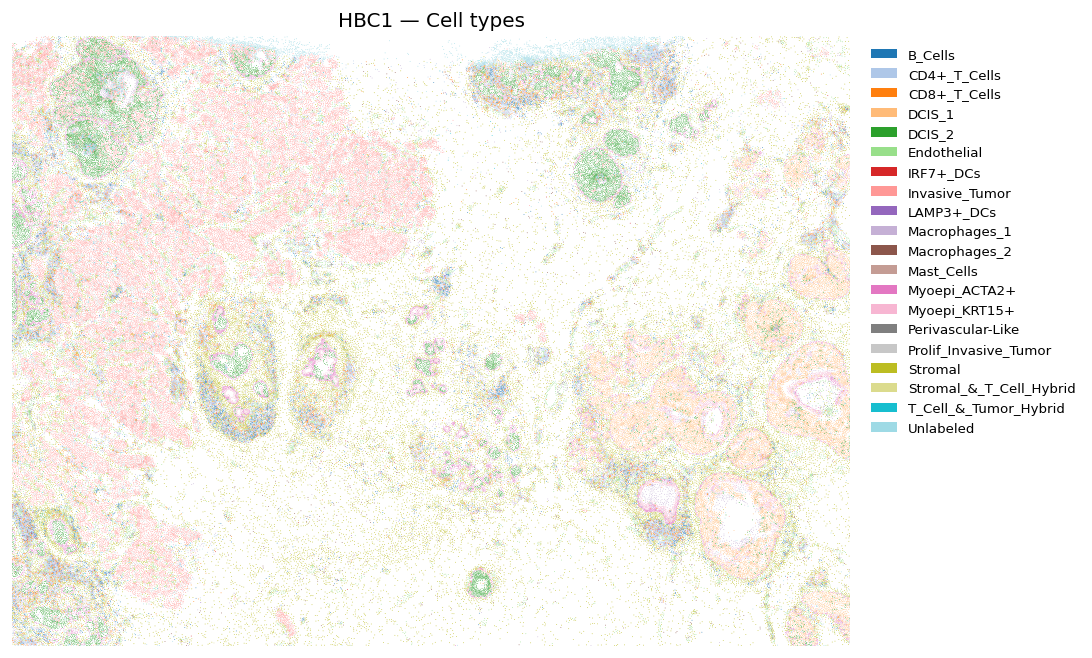

In [6]:
legend=[Patch(facecolor=type_colors[j],label=name)
        for j,name in enumerate(label_categories)]
save_spatial(type_colors[cell_type],'HBC1 — Cell types','HBC1_cell_types.png',legend)


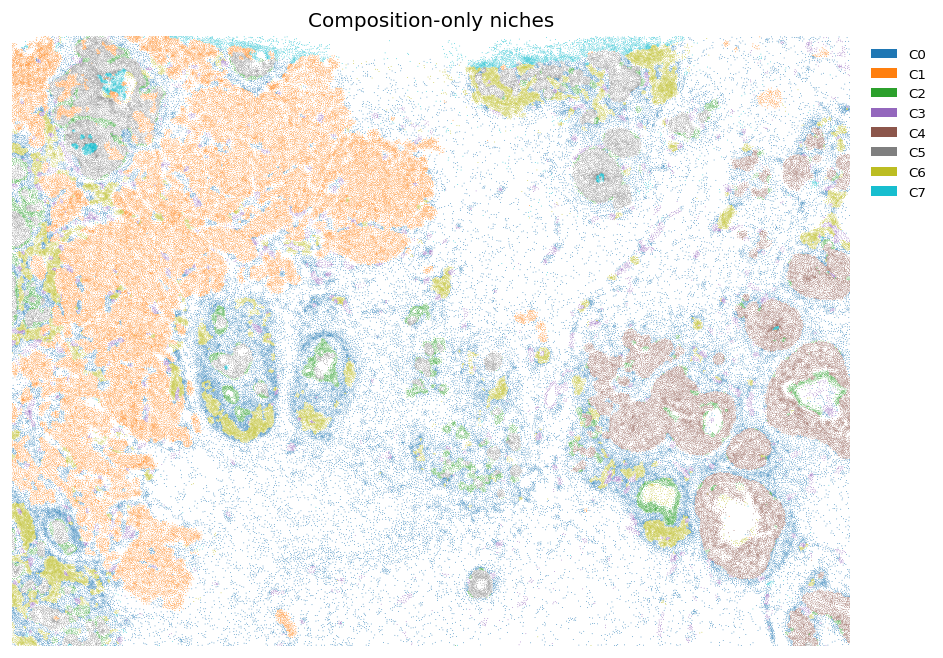

In [7]:
legend=[Patch(facecolor=single_colors[j],label=f'C{j}') for j in range(K_NICHE)]
save_spatial(single_colors[c_labels],'Composition-only niches',
             'HBC1_composition_only.png',legend)


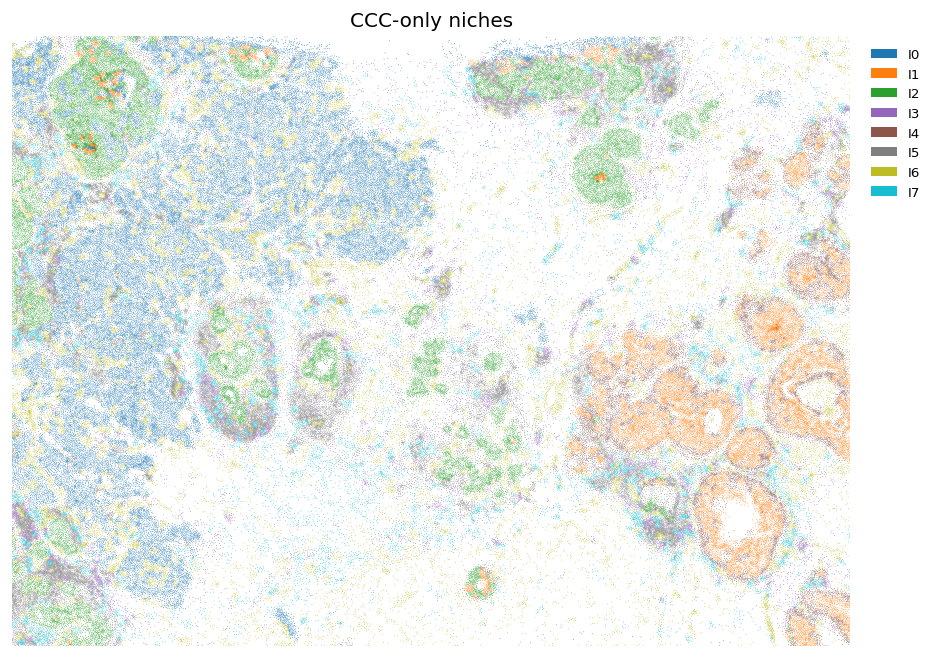

In [8]:
legend=[Patch(facecolor=single_colors[j],label=f'I{j}') for j in range(K_NICHE)]
save_spatial(single_colors[i_labels],'CCC-only niches','HBC1_CCC_only.png',legend)


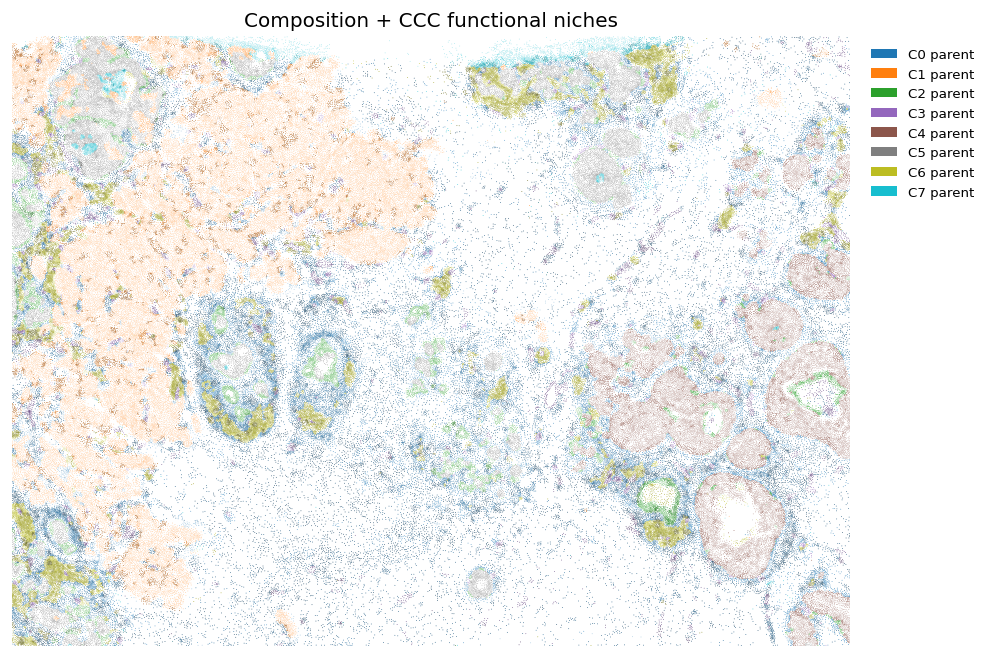

In [9]:
# One parent color family per C state; the I label changes only its shade.
legend=[Patch(facecolor=single_colors[j],label=f'C{j} parent') for j in range(K_NICHE)]
save_spatial(joint_rgb,'Composition + CCC functional niches',
             'HBC1_joint_hierarchical.png',legend)


Target composition state: C0; Region A dominant CCC state: I4; Region B dominant CCC state: I5


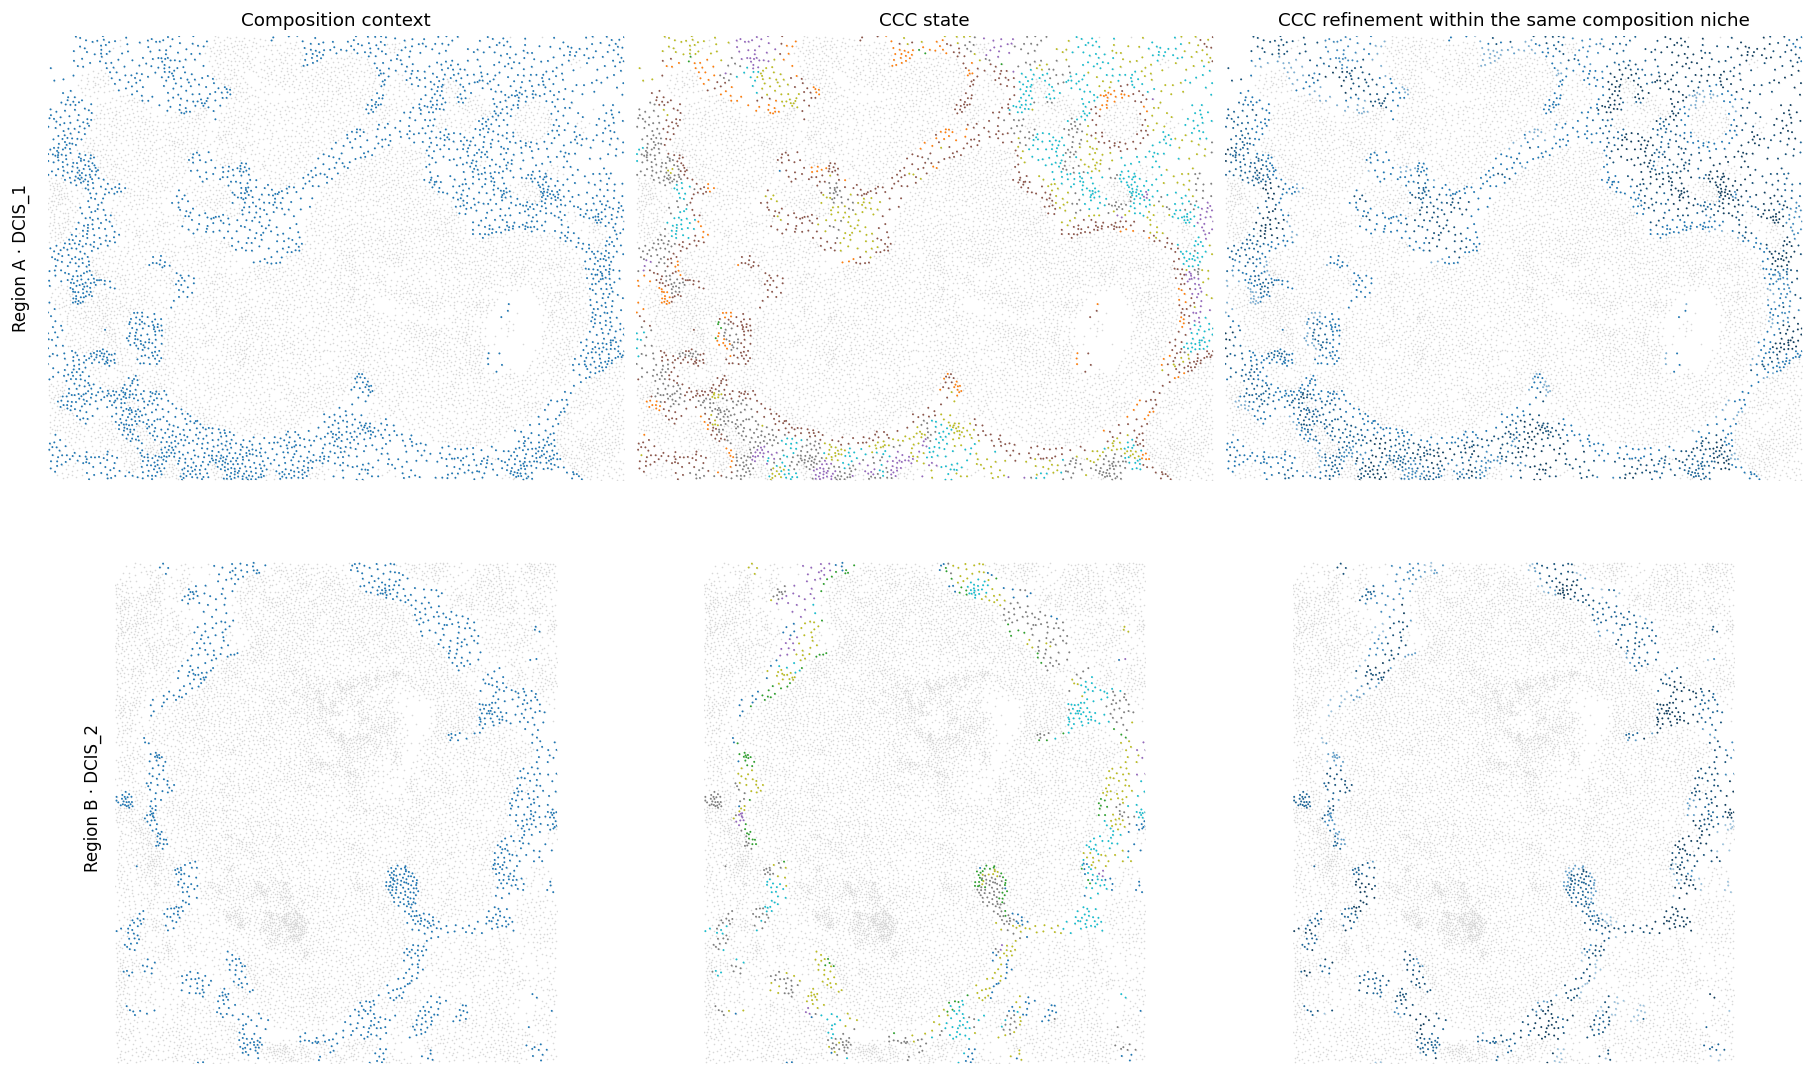

In [10]:
# Spatially define region A/B before looking at CCC labels: largest connected
# DCIS_1 and DCIS_2 components in the existing 30-NN graph.
rows=np.repeat(np.arange(N,dtype=np.int64),N_NEIGHBORS)
graph=csr_matrix((np.ones(rows.size,dtype=np.uint8),(rows,members.ravel())),shape=(N,N))
graph=graph.maximum(graph.T)
regions=[]
for name in ('DCIS_1','DCIS_2'):
    indices=np.flatnonzero(cell_type==label_categories.index(name))
    _,component=connected_components(graph[indices][:,indices],directed=False)
    largest=int(np.bincount(component).argmax())
    core=indices[component==largest]
    xy=coordinates[core]
    pad=5*SIGMA_UM   # fixed 100 µm, derived from the existing spatial scale
    box=(float(xy[:,0].min()-pad),float(xy[:,0].max()+pad),
         float(xy[:,1].min()-pad),float(xy[:,1].max()+pad))
    roi=(coordinates[:,0]>=box[0])&(coordinates[:,0]<=box[1])&(
         coordinates[:,1]>=box[2])&(coordinates[:,1]<=box[3])
    blue=roi&(c_labels==blue_state)
    if not blue.any(): raise RuntimeError(f'No blue composition cells near {name}')
    dominant=int(np.bincount(i_labels[blue],minlength=K_NICHE).argmax())
    regions.append((name,box,roi,blue,dominant))
print(f'Target composition state: C{blue_state}; '
      f'Region A dominant CCC state: I{regions[0][4]}; '
      f'Region B dominant CCC state: I{regions[1][4]}')

# Each column is one view; the two rows use the identical region/cell indices.
fig,axes=plt.subplots(2,3,figsize=(15,9),constrained_layout=True)
for row,(name,box,roi,blue,dominant) in enumerate(regions):
    ids=np.flatnonzero(roi)
    for col,ax in enumerate(axes[row]):
        ax.scatter(coordinates[ids,0],coordinates[ids,1],
                   c='#d8d8d8',s=.9,linewidths=0,rasterized=True)
        chosen=ids[c_labels[ids]==blue_state]
        colors=(np.tile(single_colors[blue_state],(len(chosen),1)) if col==0 else
                single_colors[i_labels[chosen]] if col==1 else joint_rgb[chosen])
        ax.scatter(coordinates[chosen,0],coordinates[chosen,1],
                   c=colors,s=1.35,linewidths=0,rasterized=True)
        ax.set(xlim=(box[0],box[1]),ylim=(box[3],box[2]))
        ax.set_aspect('equal'); ax.set_axis_off()
        if col==0: ax.text(-.03,.5,f'Region {"AB"[row]} · {name}',
                           rotation=90,va='center',ha='right',transform=ax.transAxes)
for ax,title in zip(axes[0],('Composition context','CCC state',
                             'CCC refinement within the same composition niche')):
    ax.set_title(title,fontsize=11)
fig.savefig(OUTPUT/'HBC1_DCIS_comparison.png',bbox_inches='tight')
plt.show()


The two DCIS-associated regions share the blue composition context, while their most common CCC states differ. The hierarchical representation retains that cellular context and records the distinct communication substates. This is a descriptive spatial observation; both regions contain mixed CCC states.